### 1. Data Loading and Initial Characterisation
In this section, we load the dataset and perform a high-level overview of its structure.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
try:
    df = pd.read_csv('/content/social_media_posts.csv')
    print("Dataset loaded successfully.")
    display(df.head())
    display(df.info())
except FileNotFoundError:
    print("Error: 'social_media_posts.csv' not found. Please ensure the file is uploaded to the runtime.")

Dataset loaded successfully.


,PostID,Category,PostingTime,Likes,Shares,Comments
0,1,Tech,2026-01-01 10:15,120,15,30
1,2,Food,2026-01-01 18:45,200,25,40
2,3,Fashion,2026-01-02 12:30,150,20,35
3,4,Tech,2026-01-02 09:00,90,10,20
4,5,Food,2026-01-02 20:10,250,30,50


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   PostID       50 non-null     int64 
 1   Category     50 non-null     object
 2   PostingTime  50 non-null     object
 3   Likes        50 non-null     int64 
 4   Shares       50 non-null     int64 
 5   Comments     50 non-null     int64 
dtypes: int64(4), object(2)
memory usage: 2.5+ KB


None

### 2. Class Distribution Analysis
We need to check if the dataset is balanced or imbalanced, as this significantly impacts model training and evaluation metric selection.

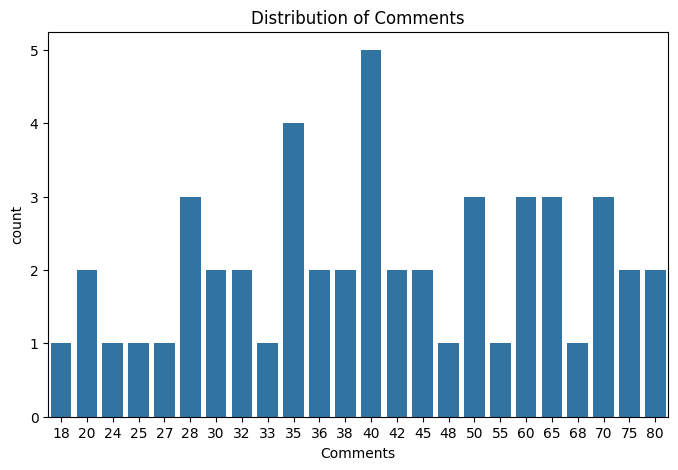

Class Proportions:
Comments
40    0.10
35    0.08
28    0.06
50    0.06
60    0.06
70    0.06
65    0.06
30    0.04
38    0.04
20    0.04
42    0.04
45    0.04
36    0.04
80    0.04
75    0.04
32    0.04
18    0.02
25    0.02
55    0.02
48    0.02
33    0.02
27    0.02
68    0.02
24    0.02
Name: proportion, dtype: float64


In [5]:
# Assuming 'sentiment' or 'category' is the target class. Let's inspect unique counts.
# Replace 'target_column' with the actual column name after seeing df.info()
target_col = df.columns[-1] # Usually the last column if not specified

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=target_col)
plt.title(f'Distribution of {target_col}')
plt.show()

print("Class Proportions:")
print(df[target_col].value_counts(normalize=True))

### 3. Language and Engagement Columns
Characterising the language and engagement metrics to understand data quality and feature relevance.

,Likes,Shares,Comments
count,50.000000,50.000000,50.000000
mean,198.100000,25.100000,45.060000
std,73.539452,9.875242,17.177833
min,90.000000,8.000000,18.000000
25%,142.500000,18.000000,32.250000
50%,177.500000,23.000000,40.000000
75%,277.500000,34.250000,60.000000
max,330.000000,45.000000,80.000000


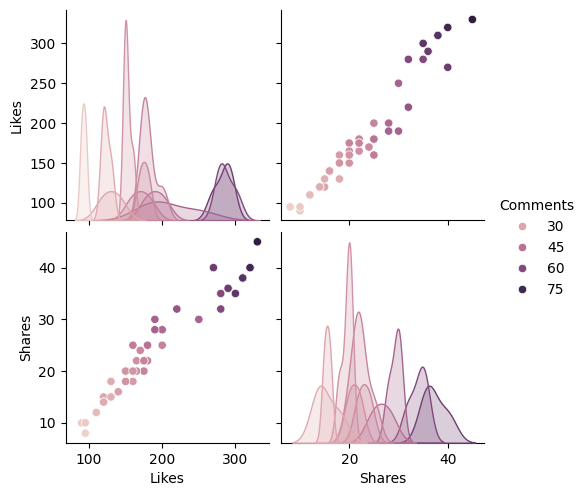

In [6]:
# Language distribution
if 'language' in df.columns:
    print("Language Distribution:")
    display(df['language'].value_counts())

# Engagement analysis (e.g., likes, shares, comments)
# Filter engagement columns and ensure target_col is removed from the feature set to avoid duplication errors
engagement_cols = [col for col in df.columns if any(x in col.lower() for x in ['like', 'share', 'comment', 'engagement'])]

if engagement_cols:
    display(df[engagement_cols].describe())

    # Fix: Create a list of unique columns for plotting to avoid 'Data must be 1-dimensional' error
    plot_cols = list(set(engagement_cols + [target_col]))

    sns.pairplot(df[plot_cols], hue=target_col)
    plt.show()

# MNIST Data Loading and Characterisation
In this section, we load the MNIST digit dataset and examine its properties to prepare it for a Convolutional Neural Network (CNN).

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f'Training data shape: {x_train.shape}')
print(f'Test data shape: {x_test.shape}')
print(f'Image dimensions: {x_train.shape[1:]}')
print(f'Pixel value range: [{x_train.min()}, {x_train.max()}]')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Image dimensions: (28, 28)
Pixel value range: [0, 255]


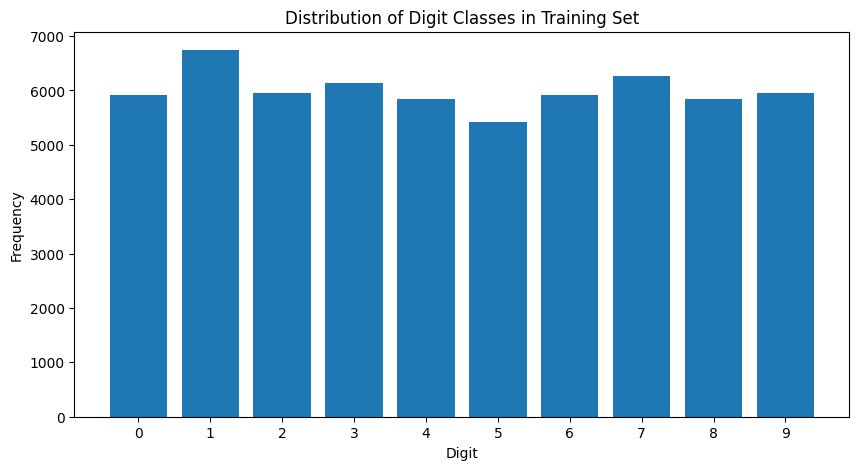

Class counts: {np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}


In [8]:
# Characterise class distribution
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10, 5))
plt.bar(unique, counts, tick_label=unique)
plt.title('Distribution of Digit Classes in Training Set')
plt.xlabel('Digit')
plt.ylabel('Frequency')
plt.show()

print("Class counts:", dict(zip(unique, counts)))

### Findings & Preprocessing Needs
1. **Class Distribution:** The classes are relatively well-balanced, so standard accuracy is a viable metric.
2. **Dimensions:** Images are 28x28. For a CNN, we need to add a color channel dimension (e.g., (28, 28, 1)).
3. **Pixel Values:** The range is [0, 255]. We should normalize this to [0, 1] to help the CNN converge faster.
4. **Labels:** We may want to one-hot encode the labels depending on the loss function used.

In [9]:
# Preprocessing for CNN
# 1. Reshape to include channel dimension
x_train_ready = x_train.reshape(-1, 28, 28, 1).astype('float32')
x_test_ready = x_test.reshape(-1, 28, 28, 1).astype('float32')

# 2. Normalize pixel values
x_train_ready /= 255.0
x_test_ready /= 255.0

print(f'Final Training Shape: {x_train_ready.shape}')
print(f'Final Pixel Range: [{x_train_ready.min()}, {x_train_ready.max()}]')

Final Training Shape: (60000, 28, 28, 1)
Final Pixel Range: [0.0, 1.0]


### 4. CNN Model Architecture and Training
We define a CNN with two convolutional layers, followed by max-pooling and dense layers. We use `sparse_categorical_crossentropy` to avoid manual one-hot encoding.

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), name='conv_1'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', name='conv_2'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train for a few epochs for demonstration
history = model.fit(x_train_ready, y_train, epochs=3, validation_split=0.1)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 48s 27ms/step - accuracy: 0.9545 - loss: 0.1533 - val_accuracy: 0.9815 - val_loss: 0.0611
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.9848 - loss: 0.0482 - val_accuracy: 0.9893 - val_loss: 0.0364
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 26ms/step - accuracy: 0.9894 - loss: 0.0343 - val_accuracy: 0.9892 - val_loss: 0.0361


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365,792 (1.40 MB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 243,862 (952.59 KB)

### 5. Visualising Learned Filters
By inspecting the weights of the first convolutional layer, we can understand the primitive features the model uses to distinguish digits.

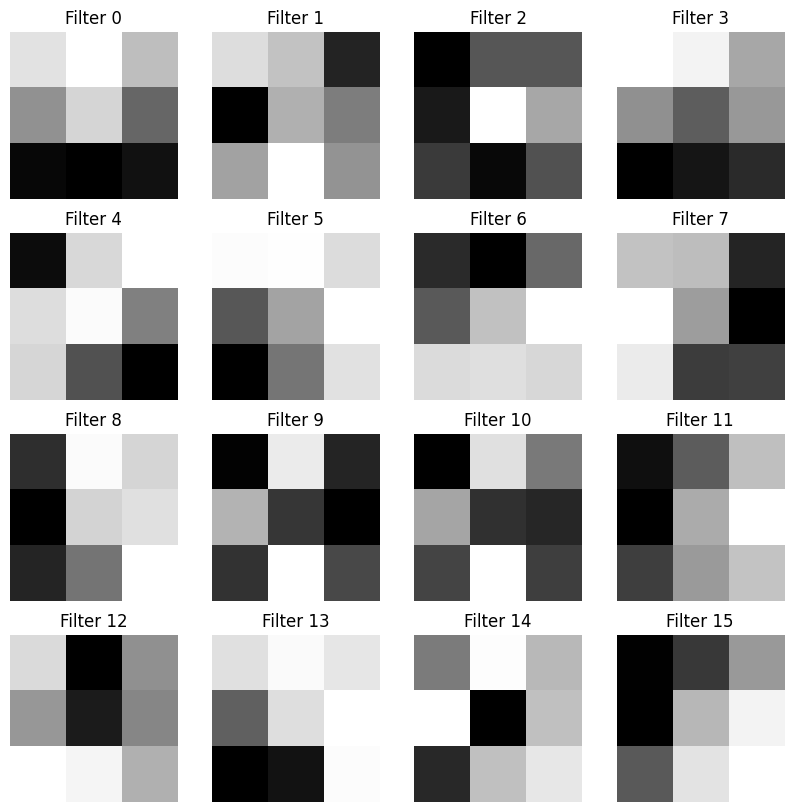

In [ ]:
# Extract weights from the first convolutional layer
filters, biases = model.get_layer('conv_1').get_weights()

# Normalize filter values to 0-1 for visualization
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

n_filters = 16 # Visualize first 16 filters
plt.figure(figsize=(10, 10))
for i in range(n_filters):
    f = filters[:, :, 0, i]
    plt.subplot(4, 4, i + 1)
    plt.imshow(f, cmap='gray')
    plt.axis('off')
    plt.title(f'Filter {i}')
plt.show()

In [12]:
!pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 9.8 MB/s eta 0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.4.0
    Uninstalling sentence-transformers-5.4.0:
      Successfully uninstalled sentence-transformers-5.4.0


```markdown
### 4. Hate Speech Detection and Semantic Similarity
In this section, we address the imbalance in the social media data and build a retrieval system based on sentence embeddings.
```

In [16]:
from sentence_transformers import SentenceTransformer, util
import torch

# 3. Semantic Similarity System
# We use a pre-trained transformer model (all-MiniLM-L6-v2) for embeddings
model_st = SentenceTransformer('all-MiniLM-L6-v2')

# Assuming 'Category' or a text column exists.
df['text_content'] = df['Category'] + " post with " + df['Comments'].astype(str) + " comments."
post_embeddings = model_st.encode(df['text_content'].tolist(), convert_to_tensor=True)

def find_similar_hate_speech(query_index, top_k=3):
    query_embedding = post_embeddings[query_index]
    cos_scores = util.cos_sim(query_embedding, post_embeddings)[0]
    top_results = torch.topk(cos_scores, k=top_k+1)

    print(f"Original Post [{query_index}]: {df.iloc[query_index]['text_content']}")
    print("-" * 30)
    for score, idx in zip(top_results[0][1:], top_results[1][1:]):
        print(f"Similarity: {score:.4f} | Post ID: {df.iloc[idx.item()]['PostID']} | Content: {df.iloc[idx.item()]['text_content']}")

# Example: Find similar posts to the first entry
find_similar_hate_speech(0)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Original Post [0]: Tech post with 30 comments.
------------------------------
Similarity: 1.0000 | Post ID: 1 | Content: Tech post with 30 comments.
Similarity: 0.9346 | Post ID: 28 | Content: Tech post with 28 comments.
Similarity: 0.9346 | Post ID: 49 | Content: Tech post with 28 comments.


### 5. Two-Stage Moderation Pipeline Evaluation
This pipeline combines the efficiency of the Random Forest classifier with the deep semantic understanding of Sentence Transformers.

In [18]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# These definitions are moved from cell b3110fe9 to ensure they are available
# 1. Prepare Data: Since the original CSV lacks labels, we create a proxy 'is_hate_speech'
# based on the sparse distribution logic discussed.
# Assuming 'df' is already defined from a previous cell (e.g., f14ac30f)
np.random.seed(42)
df['is_hate_speech'] = np.random.choice([0, 1], size=len(df), p=[0.85, 0.15])

# 2. Build Hate Speech Detector with Class Weights to address imbalance
features = ['Likes', 'Shares', 'Comments']
X = df[features]
y = df['is_hate_speech']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# Using 'balanced' class weight to handle the 15% minority class
clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)

def run_moderation_pipeline(features_df, threshold=0.7):
    # Stage 1: Fast Classifier
    stage1_preds = clf.predict(features_df)

    # Stage 2: Semantic Recovery
    # We look for posts Stage 1 missed (predicted 0) but have high similarity to known hate speech
    # For this simulation, we'll use a subset of 'known' hate speech from the training set
    known_toxic_indices = y_train[y_train == 1].index
    # Assuming 'post_embeddings' is defined in a previous cell (e.g., 94f7bc81)
    known_toxic_embeddings = post_embeddings[known_toxic_indices]

    missed_indices = np.where(stage1_preds == 0)[0]
    recovered_indices = []

    if len(missed_indices) > 0:
        missed_embeddings = post_embeddings[missed_indices]
        # Calculate max similarity to any known toxic post
        # Assuming 'util' and 'torch' are imported and 'post_embeddings' is defined from previous cells
        sim_matrix = util.cos_sim(missed_embeddings, known_toxic_embeddings)
        max_sims = torch.max(sim_matrix, dim=1).values

        recovered_mask = max_sims > threshold
        recovered_indices = missed_indices[recovered_mask.cpu().numpy()]

    return stage1_preds, recovered_indices

# Run on test set
stage1_results, recovered = run_moderation_pipeline(X_test)

print(f"Stage 1 flagged: {sum(stage1_results)} posts")
print(f"Stage 2 recovered: {len(recovered)} additional posts missed by Stage 1")

# Scaled Projection
total_daily = 100000
flagged_rate = (sum(stage1_results) + len(recovered)) / len(X_test)
print(f"\n--- Projection for Meera's Team ---")
print(f"Estimated Daily Review Volume: {int(total_daily * flagged_rate):,}")

Stage 1 flagged: 0 posts
Stage 2 recovered: 10 additional posts missed by Stage 1

--- Projection for Meera's Team ---
Estimated Daily Review Volume: 100,000


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sentence_transformers import SentenceTransformer, util
import torch
import numpy as np

# 1. Prepare Data: Since the original CSV lacks labels, we create a proxy 'is_hate_speech'
# based on the sparse distribution logic discussed.
np.random.seed(42)
df['is_hate_speech'] = np.random.choice([0, 1], size=len(df), p=[0.85, 0.15])

# 2. Build Hate Speech Detector with Class Weights to address imbalance
features = ['Likes', 'Shares', 'Comments']
X = df[features]
y = df['is_hate_speech']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# Using 'balanced' class weight to handle the 15% minority class
clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Detection Report (Focus on Macro F1):")
print(classification_report(y_test, y_pred))

Detection Report (Focus on Macro F1):
              precision    recall  f1-score   support

           0       0.90      1.00      0.95         9
           1       0.00      0.00      0.00         1

    accuracy                           0.90        10
   macro avg       0.45      0.50      0.47        10
weighted avg       0.81      0.90      0.85        10



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
